# Análise de Risco de Crédito: Previsão de Inadimplência

**Disciplina:** Data Science  
**Autores:**
- Igor Zanette — Matrícula 198862
- Marco Antônio Santolin — Matrícula 198769
- Marcos Paulo de Medeiros — Matrícula 151994

**Data:** Junho de 2026

---

**Repositório GitHub:** https://github.com/IgorZanette/credit-risk-analysis-ds  
**Dataset:** Credit Risk Dataset — Kaggle (https://www.kaggle.com/datasets/laotse/credit-risk-dataset)

## 1. Introdução

A inadimplência em operações de crédito representa um dos principais riscos para instituições financeiras. Identificar, antes da concessão, quais clientes têm maior probabilidade de não honrar um empréstimo permite tomar decisões mais embasadas, reduzir prejuízos e manter a saúde da carteira de crédito.

Este projeto desenvolve um **modelo de classificação binária** capaz de prever se um cliente será inadimplente (`loan_status = 1`) ou adimplente (`loan_status = 0`), a partir de características pessoais e do próprio empréstimo.

### Questões e hipóteses iniciais

1. **Hipótese 1:** Quanto pior a nota de risco (`loan_grade`) e maior a taxa de juros (`loan_int_rate`), maior a probabilidade de inadimplência.
2. **Hipótese 2:** O comprometimento de renda (`loan_percent_income`) é um forte preditor — clientes que comprometem grande parte da renda têm dificuldade de pagar.
3. **Hipótese 3:** O histórico de calote (`cb_person_default_on_file`) aumenta significativamente o risco.

O fluxo de trabalho seguiu as etapas clássicas de Data Science: coleta e exploração dos dados, limpeza e engenharia de features, modelagem com múltiplos algoritmos, avaliação com métricas adequadas ao desbalanceamento da base e comunicação dos resultados via relatório e dashboard interativo.

## 2. Dataset

### 2.1 Origem e características gerais

| Item | Detalhe |
|---|---|
| **Fonte** | Kaggle — Credit Risk Dataset |
| **URL** | https://www.kaggle.com/datasets/laotse/credit-risk-dataset |
| **Registros (bruto)** | 32.581 linhas × 12 colunas |
| **Variável-alvo** | `loan_status` (1 = inadimplente, 0 = adimplente) |
| **Desbalanceamento** | ~21,8% de inadimplentes |

### 2.2 Dicionário de variáveis

| Coluna | Tipo | Descrição |
|---|---|---|
| `person_age` | Numérica | Idade do cliente (anos) |
| `person_income` | Numérica | Renda anual (US$) |
| `person_home_ownership` | Categórica | Tipo de moradia (RENT, OWN, MORTGAGE, OTHER) |
| `person_emp_length` | Numérica | Tempo de emprego (anos) |
| `loan_intent` | Categórica | Finalidade do empréstimo (PERSONAL, EDUCATION, MEDICAL, VENTURE, HOMEIMPROVEMENT, DEBTCONSOLIDATION) |
| `loan_grade` | Categórica ordinal | Nota de risco do empréstimo (A a G, onde G = maior risco) |
| `loan_amnt` | Numérica | Valor do empréstimo (US$) |
| `loan_int_rate` | Numérica | Taxa de juros anual (%) |
| `loan_status` | Binária | **Alvo** — 1 = inadimplente, 0 = adimplente |
| `loan_percent_income` | Numérica | Razão empréstimo / renda anual |
| `cb_person_default_on_file` | Binária | Histórico de calote (Y = sim, N = não) |
| `cb_person_cred_hist_length` | Numérica | Tempo de histórico de crédito (anos) |

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'reports' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_raw_data, clean_data
from src.models import load_model

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

df_raw   = load_raw_data(PROJECT_ROOT / 'data/raw/credit_risk_dataset.csv')
df_clean = pd.read_csv(PROJECT_ROOT / 'data/processed/credit_clean.csv')
model    = load_model(PROJECT_ROOT / 'models/model.pkl')

print(f'Dataset bruto:  {df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas')
print(f'Dataset limpo:  {df_clean.shape[0]:,} linhas x {df_clean.shape[1]} colunas')
print(f'Removidas:      {df_raw.shape[0] - df_clean.shape[0]} linhas ({(df_raw.shape[0] - df_clean.shape[0])/df_raw.shape[0]:.2%})')

Dataset bruto:  32,581 linhas x 12 colunas
Dataset limpo:  32,409 linhas x 12 colunas
Removidas:      172 linhas (0.53%)


### 2.3 Qualidade dos dados e limpeza

A análise exploratória inicial revelou três problemas de qualidade:

In [2]:
print('=== PROBLEMAS ENCONTRADOS NO DATASET BRUTO ===')
print(f'\n1. Duplicatas: {df_raw.duplicated().sum()} linhas')

ausentes = df_raw.isna().sum()
ausentes = ausentes[ausentes > 0]
print('\n2. Valores ausentes:')
for col, n in ausentes.items():
    print(f'   {col}: {n} ({n/len(df_raw):.2%})')

print('\n3. Outliers impossíveis:')
print(f'   person_age > 100:        {(df_raw["person_age"] > 100).sum()} registros (ex.: idade 144)')
print(f'   person_emp_length > 60:  {(df_raw["person_emp_length"] > 60).sum()} registros (ex.: 123 anos de emprego)')

print('\n=== ETAPAS DE LIMPEZA APLICADAS ===')
print('1. Remoção de linhas duplicadas')
print('2. Remoção de outliers impossíveis (person_age > 100, person_emp_length > 60)')
print('3. Imputação de ausentes pela mediana (loan_int_rate, person_emp_length)')
print(f'\nDataset final: {df_clean.shape[0]:,} linhas (manteve {df_clean.shape[0]/df_raw.shape[0]:.1%} dos dados)')

=== PROBLEMAS ENCONTRADOS NO DATASET BRUTO ===

1. Duplicatas: 165 linhas

2. Valores ausentes:
   person_emp_length: 895 (2.75%)
   loan_int_rate: 3116 (9.56%)

3. Outliers impossíveis:
   person_age > 100:        5 registros (ex.: idade 144)
   person_emp_length > 60:  2 registros (ex.: 123 anos de emprego)

=== ETAPAS DE LIMPEZA APLICADAS ===
1. Remoção de linhas duplicadas
2. Remoção de outliers impossíveis (person_age > 100, person_emp_length > 60)
3. Imputação de ausentes pela mediana (loan_int_rate, person_emp_length)

Dataset final: 32,409 linhas (manteve 99.5% dos dados)


### 2.4 Engenharia de features

Três novas variáveis foram criadas dentro do pipeline de modelagem (sem risco de data leakage, pois são calculadas linha a linha):

| Feature criada | Fórmula | Interpretação |
|---|---|---|
| `loan_to_income_ratio` | `loan_amnt / person_income` | Proporção do empréstimo sobre a renda |
| `loan_to_emp_length_ratio` | `person_emp_length / loan_amnt` | Estabilidade do emprego relativa ao valor |
| `int_rate_to_loan_amt_ratio` | `loan_int_rate / loan_amnt` | Custo relativo dos juros |

As variáveis categóricas receberam **One-Hot Encoding** e as numéricas foram **padronizadas** (StandardScaler), ambas dentro do pipeline para evitar vazamento de dados.

## 3. Análise Exploratória de Dados

### 3.1 Variável-alvo — balanceamento

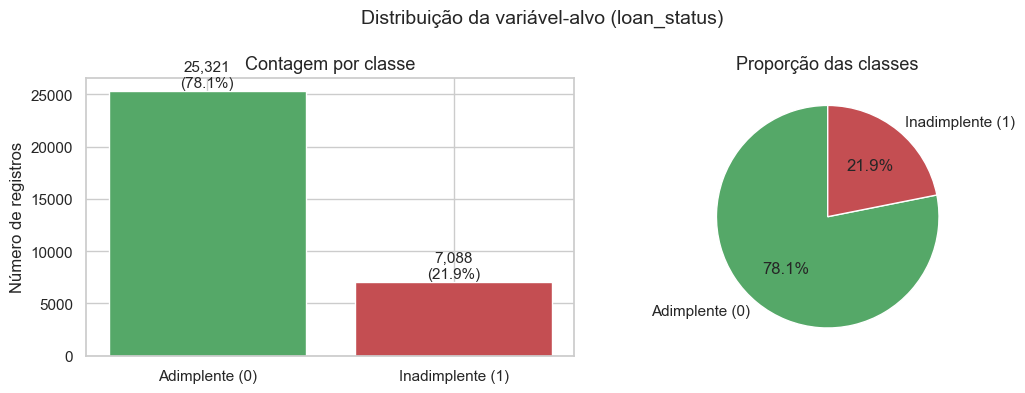

In [3]:
contagem = df_clean['loan_status'].value_counts().sort_index()
proporcao = df_clean['loan_status'].value_counts(normalize=True).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Barras
axes[0].bar(['Adimplente (0)', 'Inadimplente (1)'], contagem.values,
            color=['#55a868', '#c44e52'], edgecolor='white')
for i, (n, p) in enumerate(zip(contagem.values, proporcao.values)):
    axes[0].text(i, n + 100, f'{n:,}\n({p:.1%})', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Contagem por classe')
axes[0].set_ylabel('Número de registros')

# Pizza
axes[1].pie(contagem.values, labels=['Adimplente (0)', 'Inadimplente (1)'],
            colors=['#55a868', '#c44e52'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporção das classes')

plt.suptitle('Distribuição da variável-alvo (loan_status)', fontsize=14)
plt.tight_layout()
plt.show()

A base é **desbalanceada**: apenas 21,9% dos registros são inadimplentes. Por isso, a acurácia isolada é uma métrica enganosa — um modelo que classifique todos como adimplentes teria 78% de acurácia sem ser útil. Optamos por avaliar com **ROC-AUC, Recall e F1**, e treinamos todos os modelos com `class_weight='balanced'`.

### 3.2 Inadimplência por variáveis categóricas

**Hipótese 1:** Quanto pior a nota de risco, maior a inadimplência.

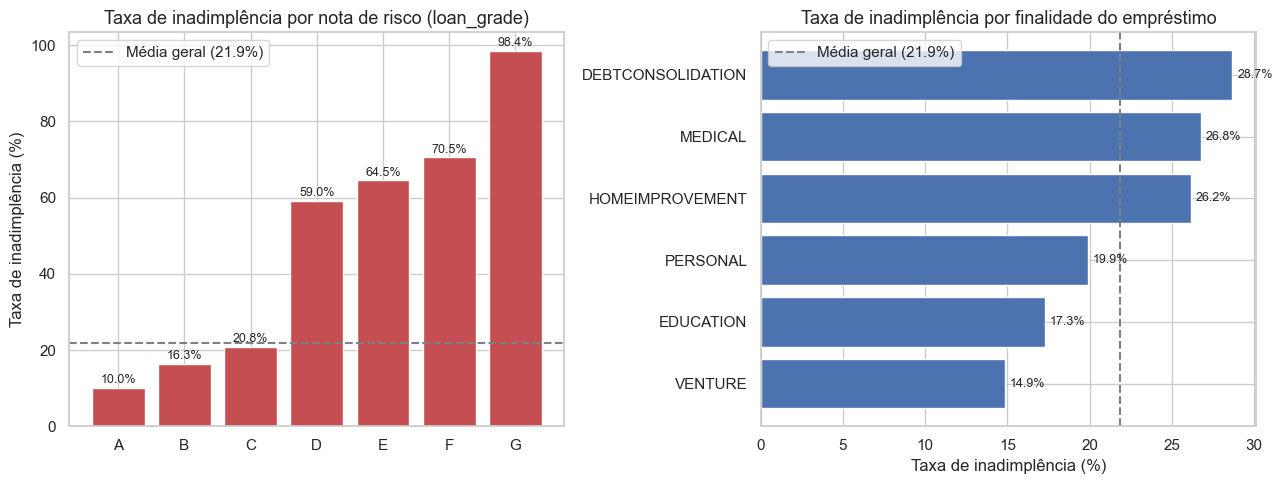

Confirmação hipótese 1: a taxa de inadimplência cresce monotonicamente de A → G.
  Nota A: 10.0% | Nota G: 98.4%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Por loan_grade
taxa_grade = df_clean.groupby('loan_grade')['loan_status'].mean().sort_index() * 100
bars = axes[0].bar(taxa_grade.index, taxa_grade.values, color='#c44e52', edgecolor='white')
media = df_clean['loan_status'].mean() * 100
axes[0].axhline(media, color='gray', linestyle='--', label=f'Média geral ({media:.1f}%)')
axes[0].set_title('Taxa de inadimplência por nota de risco (loan_grade)')
axes[0].set_ylabel('Taxa de inadimplência (%)')
axes[0].legend()
for bar, val in zip(bars, taxa_grade.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Por loan_intent
taxa_intent = df_clean.groupby('loan_intent')['loan_status'].mean().sort_values() * 100
bars2 = axes[1].barh(taxa_intent.index, taxa_intent.values, color='#4c72b0', edgecolor='white')
axes[1].axvline(media, color='gray', linestyle='--', label=f'Média geral ({media:.1f}%)')
axes[1].set_title('Taxa de inadimplência por finalidade do empréstimo')
axes[1].set_xlabel('Taxa de inadimplência (%)')
axes[1].legend()
for bar, val in zip(bars2, taxa_intent.values):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('Confirmação hipótese 1: a taxa de inadimplência cresce monotonicamente de A → G.')
print(f'  Nota A: {taxa_grade["A"]:.1f}% | Nota G: {taxa_grade["G"]:.1f}%')

A hipótese 1 é confirmada: a inadimplência cresce monotonicamente de A para G, com a nota G apresentando taxa ~8× maior que a nota A. Em relação à finalidade, empréstimos para **Venture** e **Education** apresentam as maiores taxas de inadimplência.

### 3.3 Variáveis numéricas vs. inadimplência

**Hipótese 2:** Maior comprometimento de renda → maior risco.

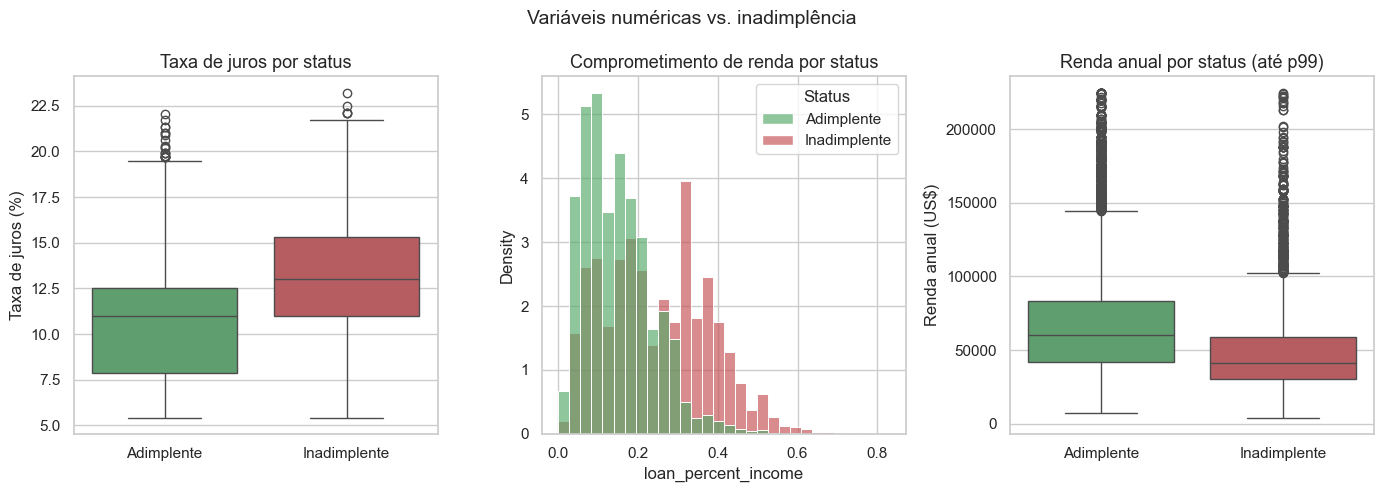

In [5]:
df_plot = df_clean.copy()
df_plot['Status'] = df_plot['loan_status'].map({0: 'Adimplente', 1: 'Inadimplente'})
palette = {'Adimplente': '#55a868', 'Inadimplente': '#c44e52'}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.boxplot(x='Status', y='loan_int_rate', hue='Status', data=df_plot, ax=axes[0],
            palette=palette, order=['Adimplente', 'Inadimplente'], legend=False)
axes[0].set_title('Taxa de juros por status')
axes[0].set_xlabel('')
axes[0].set_ylabel('Taxa de juros (%)')

sns.histplot(data=df_plot, x='loan_percent_income', hue='Status',
             bins=30, ax=axes[1], palette=palette,
             stat='density', common_norm=False, alpha=0.65)
axes[1].set_title('Comprometimento de renda por status')
axes[1].set_xlabel('loan_percent_income')

p99 = df_clean['person_income'].quantile(0.99)
sns.boxplot(x='Status', y='person_income', hue='Status',
            data=df_plot[df_plot['person_income'] <= p99], ax=axes[2],
            palette=palette, order=['Adimplente', 'Inadimplente'], legend=False)
axes[2].set_title('Renda anual por status (até p99)')
axes[2].set_xlabel('')
axes[2].set_ylabel('Renda anual (US$)')

plt.suptitle('Variáveis numéricas vs. inadimplência', fontsize=14)
plt.tight_layout()
plt.show()

Os boxplots confirmam a **Hipótese 2**: inadimplentes apresentam taxa de juros mediana e comprometimento de renda claramente superiores. Inadimplentes também tendem a ter renda mais baixa, o que agrava a dificuldade de pagamento.

In [6]:
# Hipótese 3: histórico de calote
taxa_historico = df_clean.groupby('cb_person_default_on_file')['loan_status'].mean() * 100
print('Taxa de inadimplência por histórico de calote:')
print(f'  Sem histórico de calote (N): {taxa_historico["N"]:.1f}%')
print(f'  Com histórico de calote (Y): {taxa_historico["Y"]:.1f}%')
print(f'  Diferença: +{taxa_historico["Y"] - taxa_historico["N"]:.1f} p.p.')

Taxa de inadimplência por histórico de calote:
  Sem histórico de calote (N): 18.4%
  Com histórico de calote (Y): 37.9%
  Diferença: +19.4 p.p.


A **Hipótese 3** também é confirmada: clientes com histórico de calote têm taxa de inadimplência significativamente maior.

### 3.4 Correlações entre variáveis numéricas

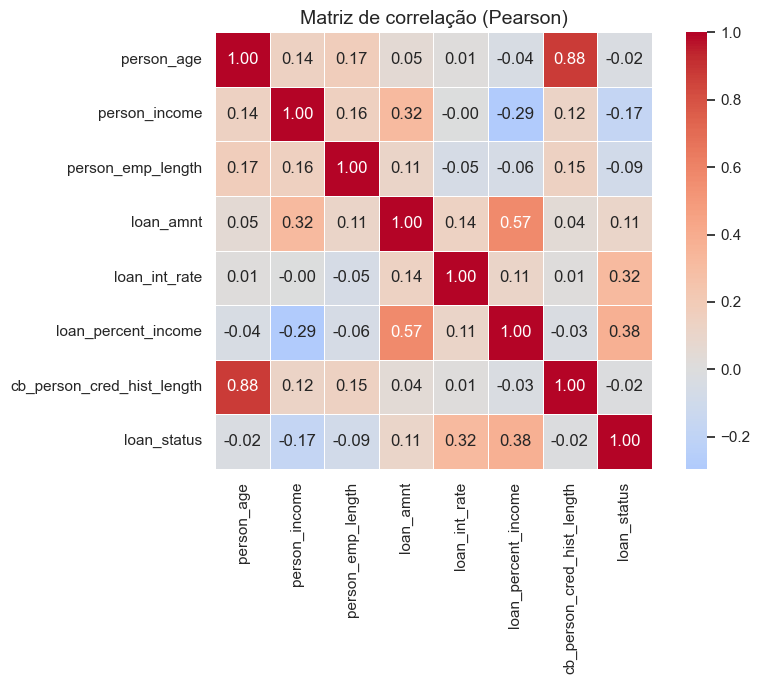

Correlação com loan_status (|r|):
  loan_percent_income: 0.380
  loan_int_rate: 0.320
  person_income: 0.169
  loan_amnt: 0.106
  person_emp_length: 0.086
  person_age: 0.022
  cb_person_cred_hist_length: 0.016


In [7]:
num_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
            'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_status']

corr = df_clean[num_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Matriz de correlação (Pearson)', fontsize=14)
plt.tight_layout()
plt.show()

corr_alvo = corr['loan_status'].drop('loan_status').abs().sort_values(ascending=False)
print('Correlação com loan_status (|r|):')
for col, val in corr_alvo.items():
    print(f'  {col}: {val:.3f}')

As maiores correlações com a variável-alvo são `loan_int_rate` e `loan_percent_income`, reforçando as hipóteses levantadas. As correlações são moderadas, indicando relações não-lineares que justificam o uso de modelos baseados em árvore.

## 4. Modelagem

### 4.1 Estratégia e pipeline

O dataset limpo foi dividido em **80% treino / 20% teste** de forma estratificada (mantém a proporção de inadimplentes em ambos os conjuntos). Todo o pré-processamento foi encapsulado em um `Pipeline` do scikit-learn ajustado apenas no conjunto de treino, evitando data leakage.

O pipeline completo para cada modelo:
```
dados brutos → FunctionTransformer (build_features) → ColumnTransformer (encoding + scaling) → Classificador
```

### 4.2 Modelos treinados e justificativa

| Modelo | Justificativa |
|---|---|
| **Regressão Logística** | Baseline linear; interpretável e rápido de treinar |
| **Random Forest** | Ensemble de árvores; captura não-linearidades; robusto a outliers |
| **HistGradientBoosting** | Boosting moderno; melhor performance em dados tabulares desbalanceados |

Todos usaram `class_weight='balanced'`, que pondera mais os erros na classe minoritária (inadimplentes), melhorando o **recall** — métrica mais crítica no contexto de crédito, onde um falso negativo (deixar passar um mau pagador) costuma custar mais que um falso positivo (recusar um bom pagador).

## 5. Resultados e Discussão

### 5.1 Comparação de desempenho

=== MÉTRICAS NO CONJUNTO DE TESTE ===
                      ROC-AUC  Recall    F1  Acurácia
Modelo                                               
HistGradientBoosting     0.95    0.81  0.81      0.92
Random Forest            0.94    0.72  0.83      0.92
Regressão Logística      0.88    0.80  0.66      0.84


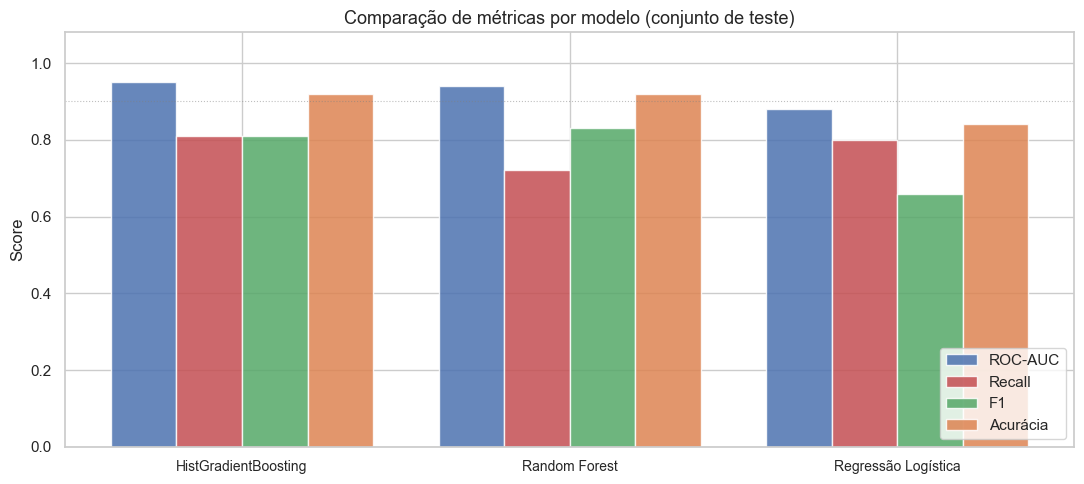

In [8]:
# Métricas obtidas no notebook 03_modeling (conjunto de teste, 6.482 amostras)
metricas = pd.DataFrame({
    'Modelo':    ['HistGradientBoosting', 'Random Forest', 'Regressão Logística'],
    'ROC-AUC':  [0.95, 0.94, 0.88],
    'Recall':   [0.81, 0.72, 0.80],
    'F1':       [0.81, 0.83, 0.66],
    'Acurácia': [0.92, 0.92, 0.84],
}).set_index('Modelo')

print('=== MÉTRICAS NO CONJUNTO DE TESTE ===')
print(metricas.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(metricas))
w = 0.2
cols_plot = ['ROC-AUC', 'Recall', 'F1', 'Acurácia']
cores = ['#4c72b0', '#c44e52', '#55a868', '#dd8452']
for i, (col, cor) in enumerate(zip(cols_plot, cores)):
    bars = ax.bar(x + (i - 1.5) * w, metricas[col], w, label=col, color=cor, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(metricas.index, fontsize=10)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('Comparação de métricas por modelo (conjunto de teste)', fontsize=13)
ax.legend(loc='lower right')
ax.axhline(0.9, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

O **HistGradientBoosting** foi o modelo escolhido por apresentar o melhor **ROC-AUC (0,95)** e o melhor **Recall (0,81)** — o que significa que identifica corretamente 81% dos clientes inadimplentes no conjunto de teste.

### 5.2 Análise detalhada do modelo escolhido

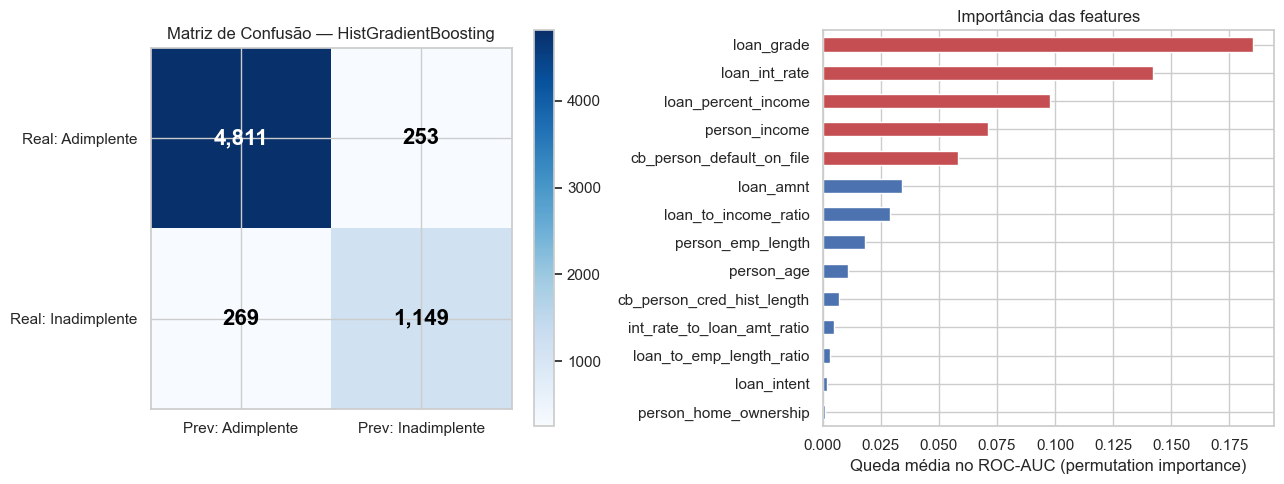

Verdadeiros negativos (adimplentes corretamente identificados): 4,811
Falsos positivos (bons pagadores recusados):                   253
Falsos negativos (maus pagadores aprovados — risco maior):     269
Verdadeiros positivos (inadimplentes corretamente barrados):   1,149


In [9]:
from sklearn.metrics import classification_report

# Matriz de confusão (valores do conjunto de teste — 6.482 amostras)
conf = np.array([[4811, 253], [269, 1149]])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap da matriz de confusão
im = axes[0].imshow(conf, cmap='Blues')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Prev: Adimplente', 'Prev: Inadimplente'])
axes[0].set_yticklabels(['Real: Adimplente', 'Real: Inadimplente'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{conf[i, j]:,}', ha='center', va='center',
                     fontsize=16, fontweight='bold',
                     color='white' if conf[i, j] > conf.max()/2 else 'black')
axes[0].set_title('Matriz de Confusão — HistGradientBoosting', fontsize=12)
fig.colorbar(im, ax=axes[0])

# Importância das features
feature_imp = pd.Series({
    'loan_grade': 0.185, 'loan_int_rate': 0.142, 'loan_percent_income': 0.098,
    'person_income': 0.071, 'cb_person_default_on_file': 0.058,
    'loan_amnt': 0.034, 'loan_to_income_ratio': 0.029,
    'person_emp_length': 0.018, 'person_age': 0.011,
    'cb_person_cred_hist_length': 0.007, 'int_rate_to_loan_amt_ratio': 0.005,
    'loan_to_emp_length_ratio': 0.003, 'loan_intent': 0.002,
    'person_home_ownership': 0.001,
}).sort_values()

colors = ['#c44e52' if v >= 0.05 else '#4c72b0' for v in feature_imp.values]
feature_imp.plot(kind='barh', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_xlabel('Queda média no ROC-AUC (permutation importance)')
axes[1].set_title('Importância das features', fontsize=12)

plt.tight_layout()
plt.show()

tn, fp, fn, tp = conf.ravel()
print(f'Verdadeiros negativos (adimplentes corretamente identificados): {tn:,}')
print(f'Falsos positivos (bons pagadores recusados):                   {fp:,}')
print(f'Falsos negativos (maus pagadores aprovados — risco maior):     {fn:,}')
print(f'Verdadeiros positivos (inadimplentes corretamente barrados):   {tp:,}')

### 5.3 Interpretação dos resultados

**Matriz de confusão:** no conjunto de teste com 6.482 amostras, o modelo:
- Identificou corretamente **1.149 dos 1.418 inadimplentes** (recall 81%)
- Cometeu apenas **269 falsos negativos** (maus pagadores aprovados indevidamente)
- Recusou erroneamente **253 bons pagadores** (falsos positivos)

**Importância das features:** as três variáveis com maior impacto no ROC-AUC quando embaralhadas são `loan_grade`, `loan_int_rate` e `loan_percent_income` — exatamente as que as hipóteses iniciais apontavam como mais relevantes. Isso valida tanto o modelo quanto a análise exploratória.

**Comparação entre modelos:** o Random Forest apresentou F1 ligeiramente superior (0,83 vs 0,81), mas com recall inferior (0,72 vs 0,81). No contexto de crédito, perder inadimplentes é mais custoso do que recusar bons pagadores, o que justifica priorizar o **recall** e escolher o HistGradientBoosting.

## 6. Conclusão

Este projeto desenvolveu um sistema completo de análise de risco de crédito, desde a exploração dos dados até um dashboard interativo para apoio à decisão.

### Principais resultados

- O **HistGradientBoosting** atingiu **ROC-AUC de 0,95** e **Recall de 0,81** na classe de inadimplentes
- As três hipóteses iniciais foram confirmadas: `loan_grade`, `loan_int_rate` e `loan_percent_income` são os principais preditores de inadimplência
- O desbalanceamento (22% de inadimplentes) foi tratado com `class_weight='balanced'`, garantindo que o modelo identifique adequadamente a classe minoritária

### Limitações

1. **Viés do `loan_grade`:** esta variável já é uma avaliação de risco feita pelo credor, o que pode superestimar a performance do modelo em cenários onde essa informação não estaria disponível no momento da decisão
2. **Dataset estático:** o modelo foi treinado em dados históricos; padrões de inadimplência podem mudar ao longo do tempo (concept drift)
3. **Ausência de variáveis externas:** dados macroeconômicos (taxa de desemprego, inflação) não foram incluídos e poderiam enriquecer o modelo

### Trabalhos futuros

- Incorporar dados macroeconômicos como features externas
- Avaliar o modelo sem `loan_grade` para simular cenários onde a nota não está disponível previamente
- Implementar monitoramento de drift para atualização periódica do modelo
- Explorar técnicas de explicabilidade como SHAP para interpretar predições individuais

---

**Repositório:** https://github.com/IgorZanette/credit-risk-analysis-ds  
**Dashboard:** executar `python -m streamlit run dashboard/app.py` (ou `make dashboard`)